# **PROYECTO FINAL – DIPLOMADO 2026**

Modelos estadísticos, Machine Learning y Deep Learning para la predicción de demanda eléctrica.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

df = pd.read_csv('complete-dataset.csv')
df['DATETIME'] = pd.to_datetime(df['DATETIME'], utc=True)
df = df.sort_values('DATETIME').set_index('DATETIME')

df_diario = df.resample('D').agg({
    'SIN': 'max',
    'T02M': 'mean',
    'ISHOLIDAY': 'max'
}).dropna().rename(columns={'SIN': 'SIN_max'})
df_diario.index = df_diario.index.tz_localize(None)

print("Datos diarios:")
display(df_diario.head())
print("\nDimensiones:", df_diario.shape)
print("Periodo:", df_diario.index.min(), "→", df_diario.index.max())

Datos diarios:


,SIN_max,T02M,ISHOLIDAY
DATETIME,,,
2008-01-01,1083.0,26.903721,1.0
2008-01-02,1296.3,27.479930,1.0
2008-01-03,1440.6,28.103424,0.0
2008-01-04,1458.0,27.575141,0.0
2008-01-05,1405.0,27.742631,0.0



Dimensiones: (5480, 3)
Periodo: 2008-01-01 00:00:00 → 2023-01-01 00:00:00


In [4]:
from sklearn.model_selection import train_test_split

In [2]:
train_size = int(len(df_diario) * 0.80)

train = df_diario.iloc[:train_size].copy()
test = df_diario.iloc[train_size:].copy()

print(f"TRAIN: {train.index.min()} → {train.index.max()} | {len(train)} datos")
print(f"TEST:  {test.index.min()} → {test.index.max()} | {len(test)} datos")

TRAIN: 2008-01-01 00:00:00+00:00 → 2020-01-01 00:00:00+00:00 | 4384 datos
TEST:  2020-01-02 00:00:00+00:00 → 2023-01-01 00:00:00+00:00 | 1096 datos


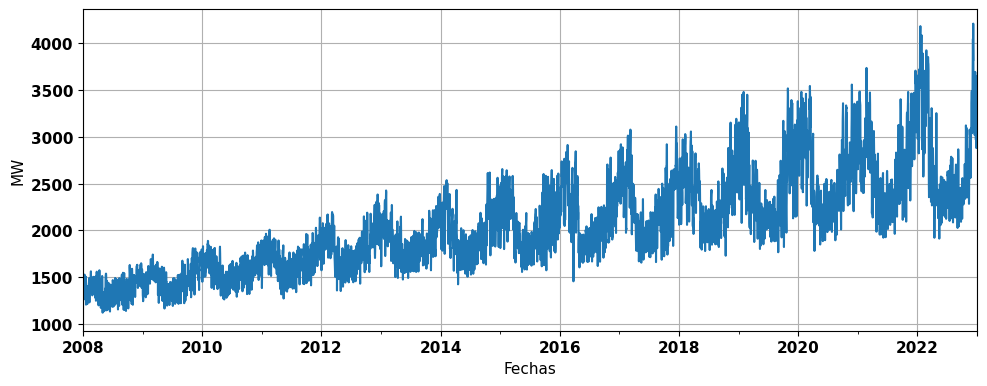

In [285]:
df_diario["SIN_max"].plot(figsize=(10,4), color="tab:blue", ylabel="MW", xlabel="Fechas", grid=True)
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f"{x:.0f}")); plt.tight_layout(); plt.show()

In [3]:
y_train = train['SIN_max']
y_test = test['SIN_max']

X_train = train[['T02M', 'ISHOLIDAY']]
X_test = test[['T02M', 'ISHOLIDAY']]

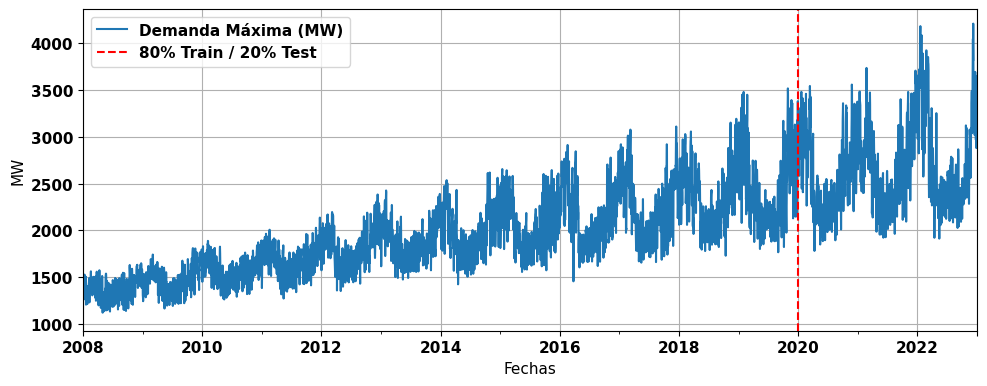

In [286]:
n = int(len(df_diario)*0.8)
fig, ax = plt.subplots(figsize=(10,4))
df_diario["SIN_max"].plot(ax=ax, color="tab:blue", label="Demanda Máxima (MW)")
ax.axvline(df_diario.index[n], color="red", linestyle="--", label="80% Train / 20% Test")
ax.set(xlabel="Fechas", ylabel="MW"); ax.ticklabel_format(axis="y", style="plain")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f"{x:.0f}")); ax.grid(True); ax.legend(); plt.tight_layout(); plt.show()

# Modelo 1 - Naïve estacional

In [5]:
H = 7
historical = y_train.copy()
naive_predictions = []

for fecha in test.index:
    pred = historical.iloc[-H]
    naive_predictions.append(pred)
    historical.loc[fecha] = test.loc[fecha, 'SIN_max']
naive_predictions = np.array(naive_predictions)
mae_naive = mean_absolute_error(y_test, naive_predictions)
rmse_naive = np.sqrt(mean_squared_error(y_test, naive_predictions))
mape_naive = np.mean(np.abs((y_test.values - naive_predictions) / y_test.values)) * 100
print("=== NAÏVE ESTACIONAL ===")
print(f"MAE:  {mae_naive:.2f} MW")
print(f"RMSE: {rmse_naive:.2f} MW")
print(f"MAPE: {mape_naive:.2f}%")

=== NAÏVE ESTACIONAL ===
MAE:  272.96 MW
RMSE: 361.59 MW
MAPE: 10.03%


# Modelo 2 - SARIMAX

In [6]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

modelo_sarimax = SARIMAX(
    y_train,
    exog=X_train,
    order=(2, 1, 2),
    seasonal_order=(1, 1, 1, 7),
    enforce_stationarity=False,
    enforce_invertibility=False
)

resultado_sarimax = modelo_sarimax.fit(disp=False, maxiter=500)

pred_sarimax = resultado_sarimax.get_forecast(
    steps=len(y_test),
    exog=X_test
).predicted_mean

mae_sarimax = mean_absolute_error(y_test, pred_sarimax)
rmse_sarimax = np.sqrt(mean_squared_error(y_test, pred_sarimax))
mape_sarimax = np.mean(
    np.abs((y_test.values - pred_sarimax.values) / y_test.values)
) * 100

print("=== SARIMAX ===")
print(f"MAE:  {mae_sarimax:.2f} MW")
print(f"RMSE: {rmse_sarimax:.2f} MW")
print(f"MAPE: {mape_sarimax:.2f}%")

=== SARIMAX ===
MAE:  437.91 MW
RMSE: 501.81 MW
MAPE: 17.67%


# Modelo 3 - Prophet

In [7]:

from prophet import Prophet

prophet_train = train.reset_index()[['DATETIME', 'SIN_max']].rename(
    columns={'DATETIME': 'ds', 'SIN_max': 'y'}
)
prophet_test = test.reset_index()[['DATETIME', 'SIN_max']].rename(
    columns={'DATETIME': 'ds', 'SIN_max': 'y'}
)

for df in [prophet_train, prophet_test]:
    df['ds'] = df['ds'].dt.tz_localize(None)

In [8]:
import warnings
from prophet import Prophet
warnings.filterwarnings("ignore")
modelo_prophet = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False
)
modelo_prophet.fit(prophet_train)

In [9]:
future = prophet_test[['ds']]
forecast_prophet = modelo_prophet.predict(future)
pred_prophet = forecast_prophet['yhat'].values

In [10]:
mae_prophet = mean_absolute_error(prophet_test['y'], pred_prophet)
rmse_prophet = np.sqrt(mean_squared_error(prophet_test['y'], pred_prophet))
mape_prophet = np.mean(
    np.abs((prophet_test['y'].values - pred_prophet) / prophet_test['y'].values)
) * 100

print("=== PROPHET ===")
print(f"MAE:  {mae_prophet:.2f} MW")
print(f"RMSE: {rmse_prophet:.2f} MW")
print(f"MAPE: {mape_prophet:.2f}%")

=== PROPHET ===
MAE:  280.06 MW
RMSE: 344.54 MW
MAPE: 10.31%


# Modelo 4 - Random Forest


In [11]:
from sklearn.ensemble import RandomForestRegressor
df_rf = df_diario.copy()
for lag in [1, 2, 3, 7, 14]:
    df_rf[f'lag_{lag}'] = df_rf['SIN_max'].shift(lag)
df_rf['dayofweek'] = df_rf.index.dayofweek
df_rf['month'] = df_rf.index.month
df_rf = df_rf.dropna()
print(df_rf.head().to_string())

                           SIN_max       T02M  ISHOLIDAY   lag_1   lag_2   lag_3   lag_7  lag_14  dayofweek  month
DATETIME                                                                                                          
2008-01-15 00:00:00+00:00   1491.0  29.530271        0.0  1343.5  1334.5  1263.6  1456.0  1083.0          1      1
2008-01-16 00:00:00+00:00   1507.0  29.087917        0.0  1491.0  1343.5  1334.5  1467.0  1296.3          2      1
2008-01-17 00:00:00+00:00   1473.0  29.515295        0.0  1507.0  1491.0  1343.5  1490.0  1440.6          3      1
2008-01-18 00:00:00+00:00   1503.0  28.368604        0.0  1473.0  1507.0  1491.0  1526.7  1458.0          4      1
2008-01-19 00:00:00+00:00   1483.9  25.460489        0.0  1503.0  1473.0  1507.0  1263.6  1405.0          5      1


In [12]:
features_rf = [
    'lag_1', 'lag_2', 'lag_3', 'lag_7', 'lag_14',
    'T02M', 'ISHOLIDAY', 'dayofweek', 'month'
]
X_rf = df_rf[features_rf]
y_rf = df_rf['SIN_max']

In [13]:
X_rf_train, X_rf_test, y_rf_train, y_rf_test = train_test_split(
    X_rf, y_rf, train_size=0.8, shuffle=False, random_state=42
)

In [14]:
from sklearn.ensemble import RandomForestRegressor
modelo_rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)
modelo_rf.fit(X_rf_train, y_rf_train)
pred_rf = modelo_rf.predict(X_rf_test)
mae_rf = mean_absolute_error(y_rf_test, pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_rf_test, pred_rf))
mape_rf = np.mean(np.abs((y_rf_test.values - pred_rf) / y_rf_test.values)) * 100
print("=== RANDOM FOREST ===")
print(f"MAE:  {mae_rf:.2f} MW")
print(f"RMSE: {rmse_rf:.2f} MW")
print(f"MAPE: {mape_rf:.2f}%")

=== RANDOM FOREST ===
MAE:  239.46 MW
RMSE: 296.85 MW
MAPE: 8.46%


In [15]:
comparacion_modelos = pd.DataFrame({
    'Modelo': ['Naïve', 'SARIMAX', 'Prophet', 'Random Forest'],
    'MAE (MW)': [mae_naive, mae_sarimax, mae_prophet, mae_rf],
    'RMSE (MW)': [rmse_naive, rmse_sarimax, rmse_prophet, rmse_rf],
    'MAPE (%)': [mape_naive, mape_sarimax, mape_prophet, mape_rf]
}).round(2)

display(comparacion_modelos)

,Modelo,MAE (MW),RMSE (MW),MAPE (%)
0,Naïve,272.96,361.59,10.03
1,SARIMAX,437.91,501.81,17.67
2,Prophet,280.06,344.54,10.31
3,Random Forest,239.46,296.85,8.46


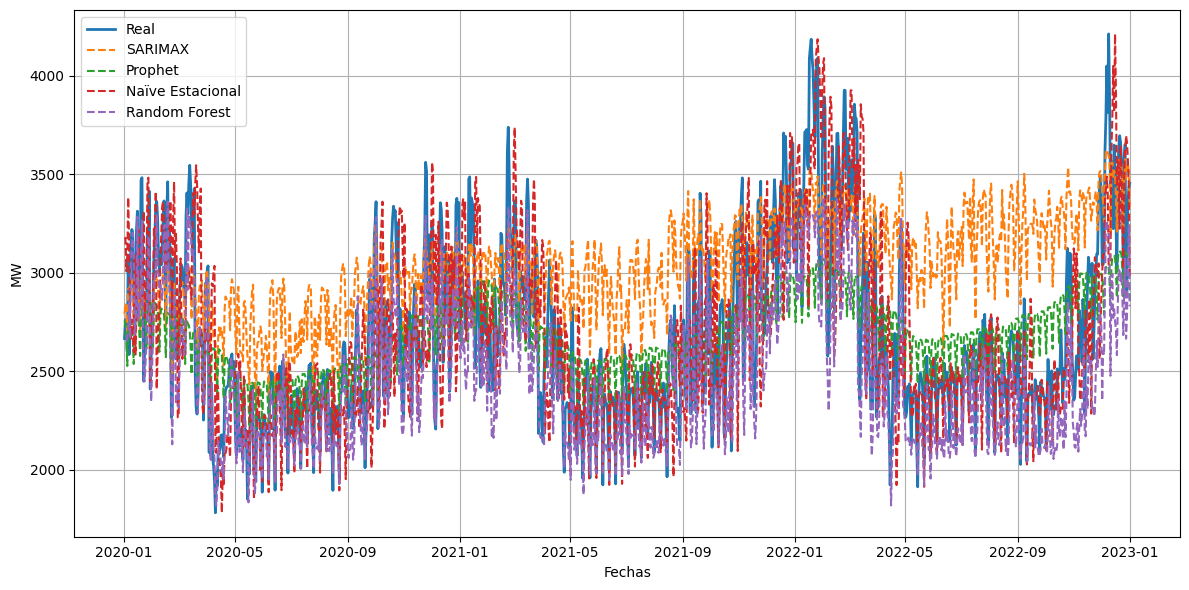

In [16]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 6))
plt.plot(y_test.index, y_test, label='Real', linewidth=2)
plt.plot(y_test.index, pred_sarimax, label='SARIMAX', linestyle='--')
plt.plot(prophet_test['ds'], pred_prophet, label='Prophet', linestyle='--')
plt.plot(y_test.index, naive_predictions, label='Naïve Estacional', linestyle='--')
plt.plot(y_rf_test.index, pred_rf, label='Random Forest', linestyle='--')
plt.xlabel('Fechas')
plt.ylabel('MW')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

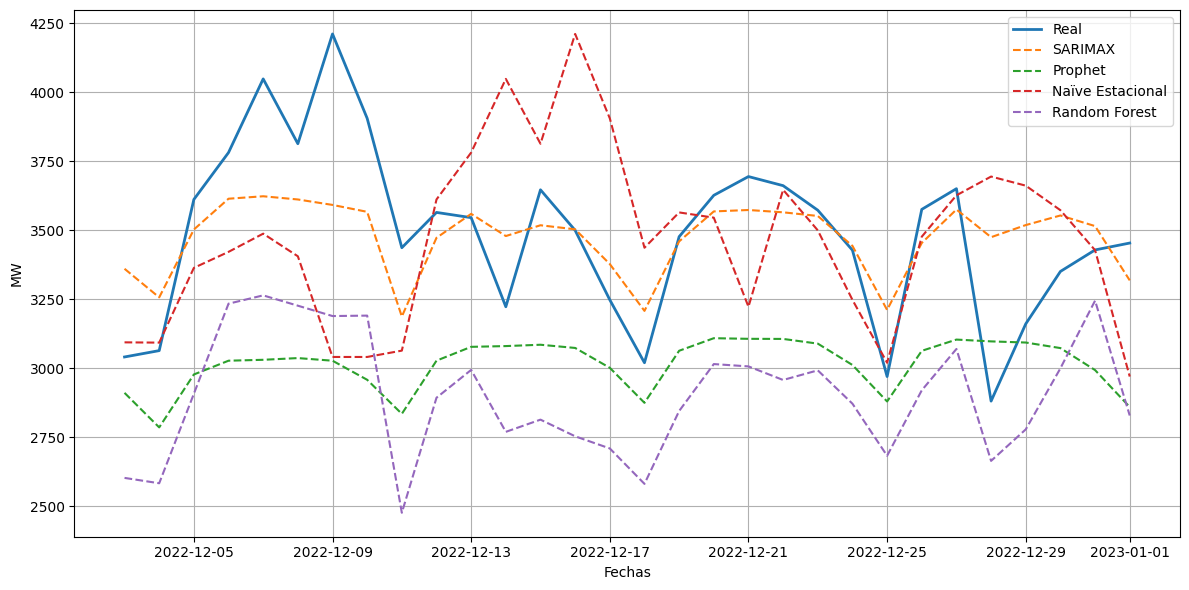

In [17]:
import matplotlib.pyplot as plt
dias = 30
plt.figure(figsize=(12, 6))
plt.plot(y_test.index[-dias:], y_test.iloc[-dias:], label='Real', linewidth=2)
plt.plot(y_test.index[-dias:], pred_sarimax[-dias:], label='SARIMAX', linestyle='--')
plt.plot(prophet_test['ds'].iloc[-dias:], pred_prophet[-dias:], label='Prophet', linestyle='--')
plt.plot(y_test.index[-dias:], naive_predictions[-dias:], label='Naïve Estacional', linestyle='--')
plt.plot(y_rf_test.index[-dias:], pred_rf[-dias:], label='Random Forest', linestyle='--')
plt.xlabel('Fechas')
plt.ylabel('MW')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('comparacion_ultimos_30_dias.png', dpi=300, bbox_inches='tight')
plt.show()

# Modelo 5 - MLP

In [18]:
features = [
    "lag_1",
    "lag_2",
    "lag_3",
    "lag_7",
    "lag_14",
    "T02M",
    "ISHOLIDAY",
    "dayofweek",
    "month"
]
X_rf = df_rf[features]
y_rf = df_rf["SIN_max"]
train_size_rf = int(len(df_rf) * 0.80)
X_train = X_rf.iloc[:train_size_rf]
X_test  = X_rf.iloc[train_size_rf:]
y_train = y_rf.iloc[:train_size_rf]
y_test  = y_rf.iloc[train_size_rf:]

In [19]:
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
scaler_mlp = StandardScaler()
X_train_mlp = scaler_mlp.fit_transform(X_train)
X_test_mlp = scaler_mlp.transform(X_test)
modelo_mlp = MLPRegressor(
    hidden_layer_sizes=(64, 32),
    max_iter=1000,
    random_state=42
)
modelo_mlp.fit(X_train_mlp, y_train)
pred_mlp = modelo_mlp.predict(X_test_mlp)

In [20]:
mae_mlp = mean_absolute_error(y_test, pred_mlp)
rmse_mlp = np.sqrt(mean_squared_error(y_test, pred_mlp))
mape_mlp = np.mean(np.abs((y_test.values - pred_mlp) / y_test.values)) * 100

print("=== MLP ===")
print(f"MAE:  {mae_mlp:.2f} MW")
print(f"RMSE: {rmse_mlp:.2f} MW")
print(f"MAPE: {mape_mlp:.2f}%")

=== MLP ===
MAE:  153.17 MW
RMSE: 192.53 MW
MAPE: 5.66%


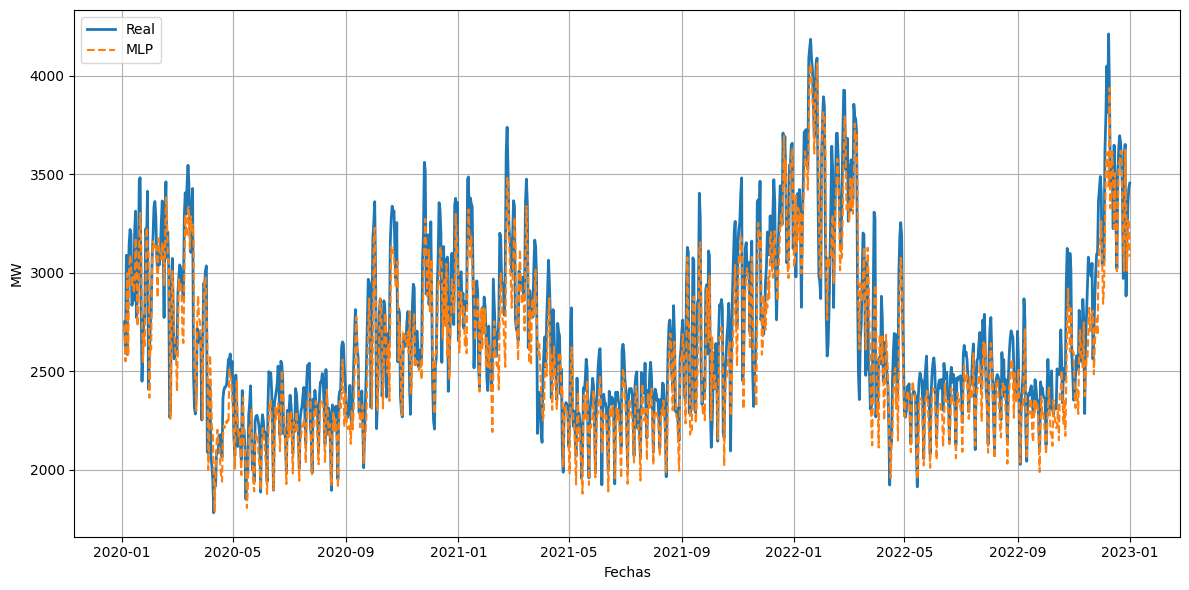

In [21]:
plt.figure(figsize=(12, 6))
plt.plot(y_test.index, y_test, label='Real', linewidth=2)
plt.plot(y_test.index, pred_mlp, label='MLP', linestyle='--')
plt.xlabel('Fechas')
plt.ylabel('MW')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('real_vs_mlp.png', dpi=300, bbox_inches='tight')
plt.show()

# MODELO 6 - XGBOOST

In [22]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
modelo_xgb = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    objective='reg:squarederror',
    eval_metric='rmse',
    random_state=42,
    n_jobs=2
)
# Entrenamiento
modelo_xgb.fit(X_rf_train, y_rf_train)
# Predicciones
pred_xgb = modelo_xgb.predict(X_rf_test)
# Evaluación de métricas
mae_xgb = mean_absolute_error(y_rf_test, pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_rf_test, pred_xgb))
mape_xgb = np.mean(
    np.abs((y_rf_test.values - pred_xgb) / y_rf_test.values)
) * 100
print("=== XGBOOST ===")
print(f"MAE:  {mae_xgb:.2f} MW")
print(f"RMSE: {rmse_xgb:.2f} MW")
print(f"MAPE: {mape_xgb:.2f}%")

=== XGBOOST ===
MAE:  221.01 MW
RMSE: 275.52 MW
MAPE: 7.82%


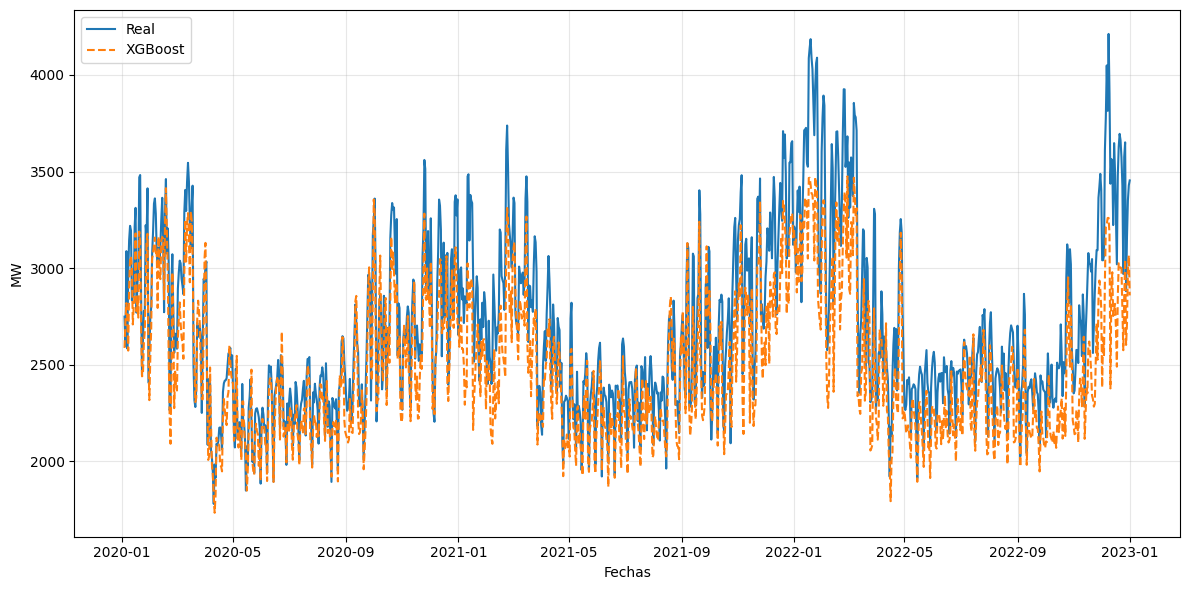

In [23]:
plt.figure(figsize=(12, 6))
plt.plot(y_rf_test.index, y_rf_test, label='Real')
plt.plot(y_rf_test.index, pred_xgb, label='XGBoost', linestyle='--')
plt.xlabel('Fechas')
plt.ylabel('MW')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# MODELO 7 - SVR

In [24]:
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

modelo_svr = make_pipeline(
    StandardScaler(),
    #SVR(kernel='rbf', C=10, epsilon=0.1, gamma='scale')
    SVR(kernel='rbf', C=100, epsilon=0.2, gamma=0.01)
)
modelo_svr.fit(X_rf_train, y_rf_train)
pred_svr = modelo_svr.predict(X_rf_test)
mae_svr = mean_absolute_error(y_rf_test, pred_svr)
rmse_svr = np.sqrt(mean_squared_error(y_rf_test, pred_svr))
mape_svr = np.mean(
    np.abs((y_rf_test.values - pred_svr) / y_rf_test.values)
) * 100
print("=== SVR ===")
print(f"MAE:  {mae_svr:.2f} MW")
print(f"RMSE: {rmse_svr:.2f} MW")
print(f"MAPE: {mape_svr:.2f}%")

=== SVR ===
MAE:  181.54 MW
RMSE: 251.36 MW
MAPE: 6.24%


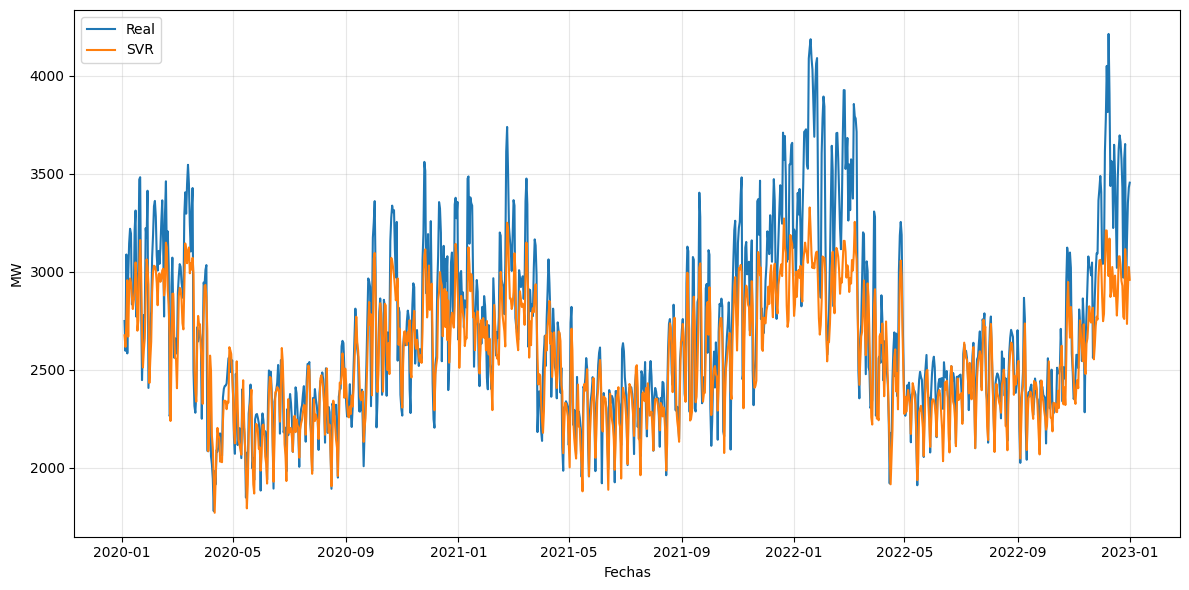

In [25]:
plt.figure(figsize=(12, 6))
plt.plot(y_rf_test.index, y_rf_test,
         label='Real', linewidth=1.5)
plt.plot(y_rf_test.index, pred_svr,
         label='SVR', linewidth=1.5)
plt.xlabel('Fechas')
plt.ylabel('MW')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [26]:
!pip install -q darts

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.9/67.9 kB 2.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.3/60.3 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 841.3/841.3 kB 17.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 17.8 MB/s eta 0:00:00


In [27]:
from darts import TimeSeries
from darts.dataprocessing.transformers import Scaler
# Series de consumo y covariables
serie_train = TimeSeries.from_dataframe(train, value_cols='SIN_max')
serie_test = TimeSeries.from_dataframe(test, value_cols='SIN_max')

cov_train = TimeSeries.from_dataframe(
    train, value_cols=['T02M', 'ISHOLIDAY']
)
cov_test = TimeSeries.from_dataframe(
    test, value_cols=['T02M', 'ISHOLIDAY']
)
# Escalado
scaler_y = Scaler()
scaler_x = Scaler()
serie_train_s = scaler_y.fit_transform(serie_train)
serie_test_s = scaler_y.transform(serie_test)
cov_train_s = scaler_x.fit_transform(cov_train)
cov_test_s = scaler_x.transform(cov_test)
cov_full_s = cov_train_s.append(cov_test_s)

# MODELO 8 - LSTM

In [28]:
!pip install -q "u8darts[torch]"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 1.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.9/62.9 kB 2.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 1.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 744.5/744.5 kB 13.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 825.4/825.4 kB 9.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.5/87.5 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.5/16.5 MB 16.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 12.6 MB/s eta 0:00:00


In [32]:
from darts import TimeSeries

from darts.dataprocessing.transformers import Scaler
print("Darts + PyTorch OK")

Darts + PyTorch OK


In [33]:
serie_train = TimeSeries.from_dataframe(train, value_cols='SIN_max')
serie_test = TimeSeries.from_dataframe(test, value_cols='SIN_max')

cov_train = TimeSeries.from_dataframe(
    train, value_cols=['T02M', 'ISHOLIDAY']
)
cov_test = TimeSeries.from_dataframe(
    test, value_cols=['T02M', 'ISHOLIDAY']
)
scaler_y = Scaler()
scaler_x = Scaler()

serie_train_s = scaler_y.fit_transform(serie_train)
serie_test_s = scaler_y.transform(serie_test)
cov_train_s = scaler_x.fit_transform(cov_train)
cov_test_s = scaler_x.transform(cov_test)
cov_full_s = cov_train_s.append(cov_test_s)

In [34]:
!pip uninstall -y darts u8darts
!pip install -U "darts[torch]"

Found existing installation: darts 0.41.0
Uninstalling darts-0.41.0:
  Successfully uninstalled darts-0.41.0
Found existing installation: u8darts 0.41.0
Uninstalling u8darts-0.41.0:
  Successfully uninstalled u8darts-0.41.0
  Using cached darts-0.47.0-py3-none-any.whl.metadata (67 kB)
Using cached darts-0.47.0-py3-none-any.whl (841 kB)


In [37]:
from darts.models import RNNModel
modelo_lstm = RNNModel(
    model='LSTM',
    input_chunk_length=30,
    output_chunk_length=7,
    hidden_dim=64,
    n_rnn_layers=2,
    dropout=0.2,
    batch_size=16,
    n_epochs=50,
    optimizer_kwargs={'lr': 0.001},
    random_state=42,
    training_length=37
)

In [38]:
modelo_lstm.fit(
    serie_train_s,
    future_covariates=cov_train_s,
    verbose=False
)
pred_lstm_s = modelo_lstm.predict(
    n=len(serie_test_s),
    future_covariates=cov_full_s
)
pred_lstm = scaler_y.inverse_transform(pred_lstm_s)

INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=50` reached.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs


Predicting: |          | 0/? [00:00<?, ?it/s]

In [39]:
real = serie_test.values().flatten()
lstm = pred_lstm.values().flatten()

mae_lstm = mean_absolute_error(real, lstm)
rmse_lstm = np.sqrt(mean_squared_error(real, lstm))
mape_lstm = np.mean(np.abs((real - lstm) / real)) * 100

print(f"MAE:  ️{mae_lstm:.2f} MW")
print(f"RMSE: {rmse_lstm:.2f} MW")
print(f"MAPE: {mape_lstm:.2f}%")

MAE:  ️537.43 MW
RMSE: 623.92 MW
MAPE: 19.11%


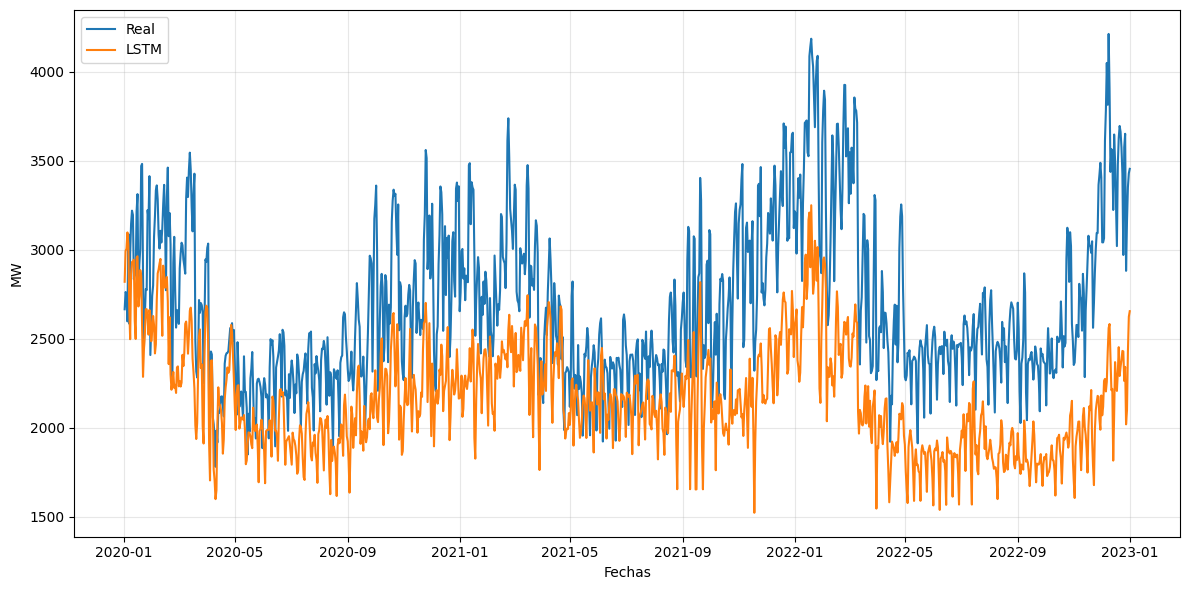

In [40]:
plt.figure(figsize=(12, 6))
plt.plot(serie_test.time_index, serie_test.values().flatten(),
         label='Real', linewidth=1.5)
plt.plot(pred_lstm.time_index, pred_lstm.values().flatten(),
         label='LSTM', linewidth=1.5)
plt.xlabel('Fechas')
plt.ylabel('MW')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# MODELO 9 - GRU

In [41]:
modelo_gru = RNNModel(
    model='GRU',
    input_chunk_length=30,
    output_chunk_length=7,
    hidden_dim=64,
    n_rnn_layers=2,
    dropout=0.1,
    batch_size=16,
    n_epochs=80,
    optimizer_kwargs={'lr': 0.001},
    random_state=42,
    training_length=37
)

In [42]:
modelo_gru.fit(
    serie_train_s,
    future_covariates=cov_train_s,
    verbose=False
)
pred_gru_s = modelo_gru.predict(
    n=len(serie_test_s),
    future_covariates=cov_full_s
)
pred_gru = scaler_y.inverse_transform(pred_gru_s)

INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=80` reached.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs


Predicting: |          | 0/? [00:00<?, ?it/s]

In [45]:
real = serie_test.values().flatten()
gru = pred_gru.values().flatten()

mae_gru = mean_absolute_error(real, gru)
rmse_gru = np.sqrt(mean_squared_error(real, gru))
mape_gru = np.mean(np.abs((real - gru) / real)) * 100

print("========== GRU ==========")
print(f"MAE:  {mae_gru:.2f} MW")
print(f"RMSE: {rmse_gru:.2f} MW")
print(f"MAPE: {mape_gru:.2f}%")


========== GRU ==========
MAE:  219.99 MW
RMSE: 281.03 MW
MAPE: 7.99%


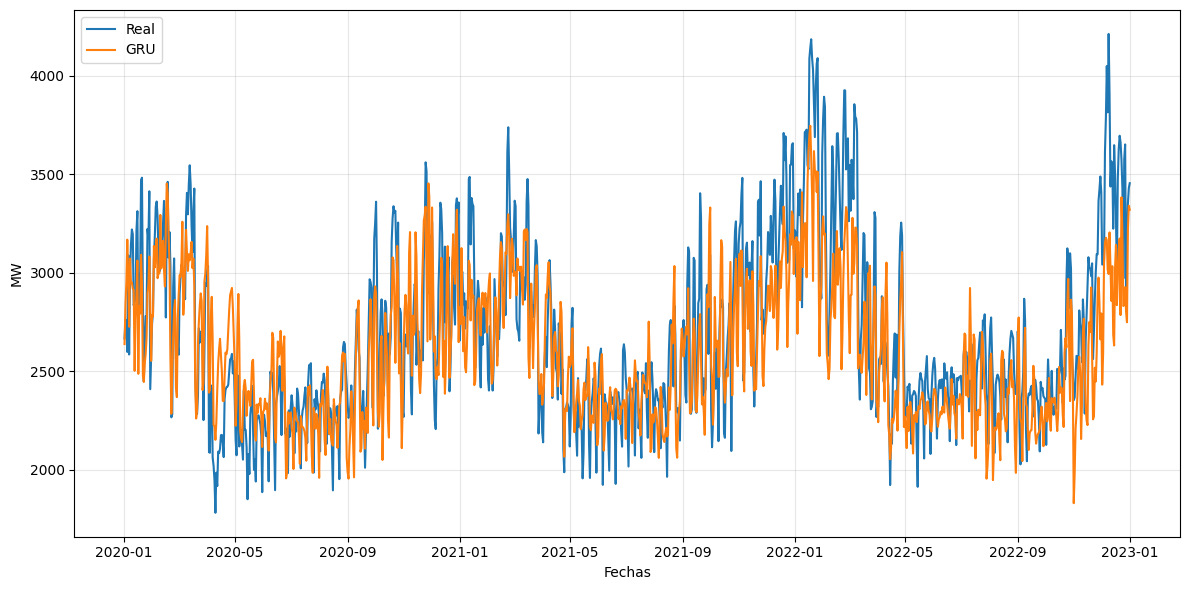

In [46]:
plt.figure(figsize=(12, 6))
plt.plot(
    serie_test.time_index,
    real,
    label='Real',
    linewidth=1.5
)
plt.plot(
    pred_gru.time_index,
    gru,
    label='GRU',
    linewidth=1.5
)
plt.xlabel('Fechas')
plt.ylabel('MW')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# **COMPARATIVA DE MODELOS**

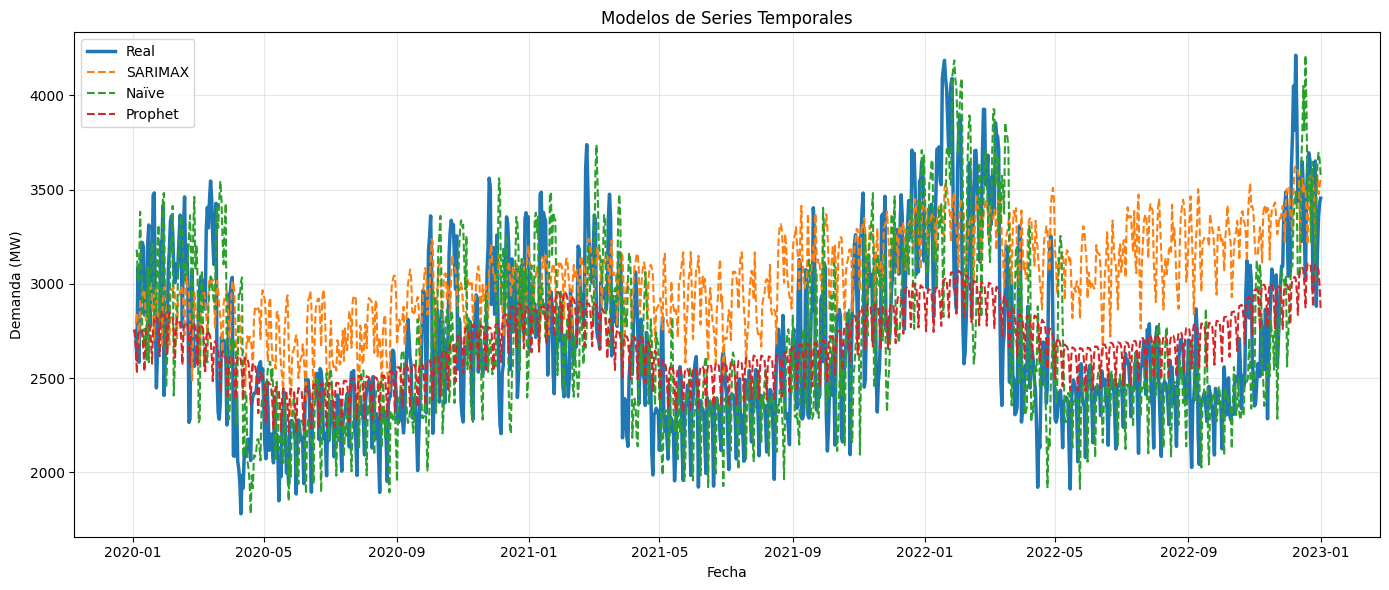

In [49]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))
plt.plot(y_test.index, y_test, label='Real', linewidth=2.5)
for nombre, pred in {
    'SARIMAX': pred_sarimax,
    'Naïve': naive_predictions
}.items():
    n = min(len(y_test), len(pred))
    plt.plot(y_test.index[:n], pred[:n], '--', label=nombre)
n = min(len(prophet_test), len(pred_prophet))
plt.plot(prophet_test['ds'][:n], pred_prophet[:n], '--', label='Prophet')

plt.title('Modelos de Series Temporales')
plt.xlabel('Fecha')
plt.ylabel('Demanda (MW)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

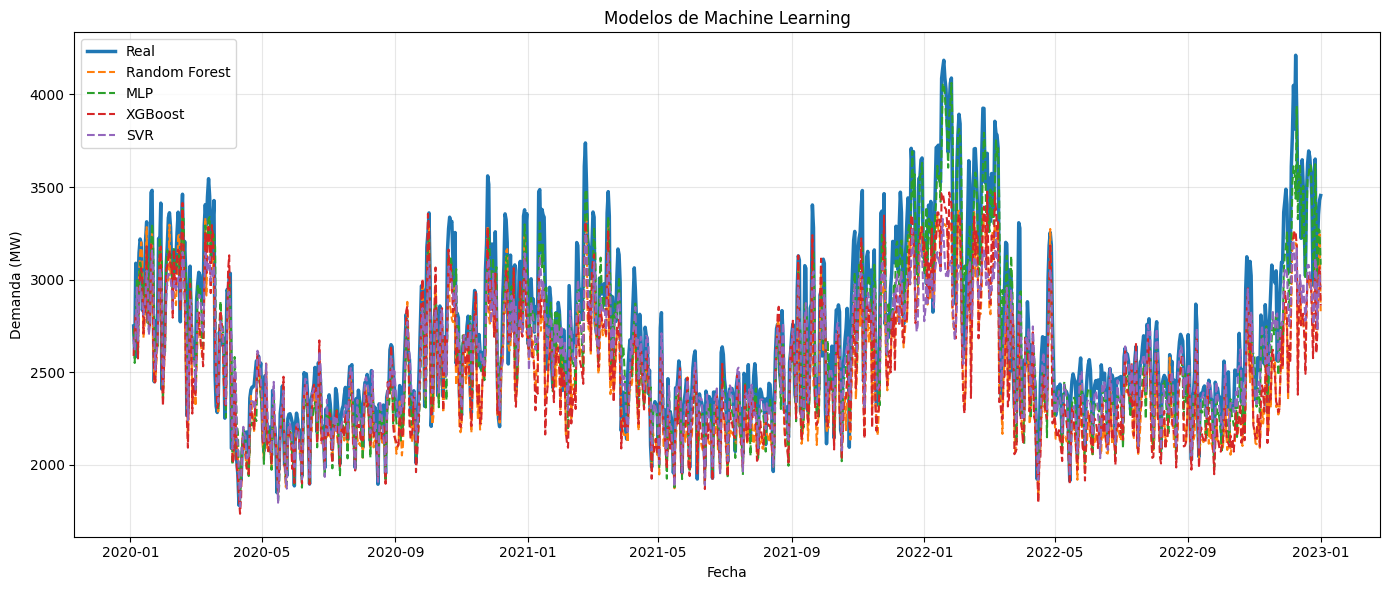

In [50]:
plt.figure(figsize=(14, 6))
plt.plot(y_test.index, y_test, label='Real', linewidth=2.5)

for nombre, pred in {
    'Random Forest': pred_rf,
    'MLP': pred_mlp,
    'XGBoost': pred_xgb,
    'SVR': pred_svr
}.items():
    plt.plot(y_rf_test.index, pred, '--', label=nombre)

plt.title('Modelos de Machine Learning')
plt.xlabel('Fecha'); plt.ylabel('Demanda (MW)')
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

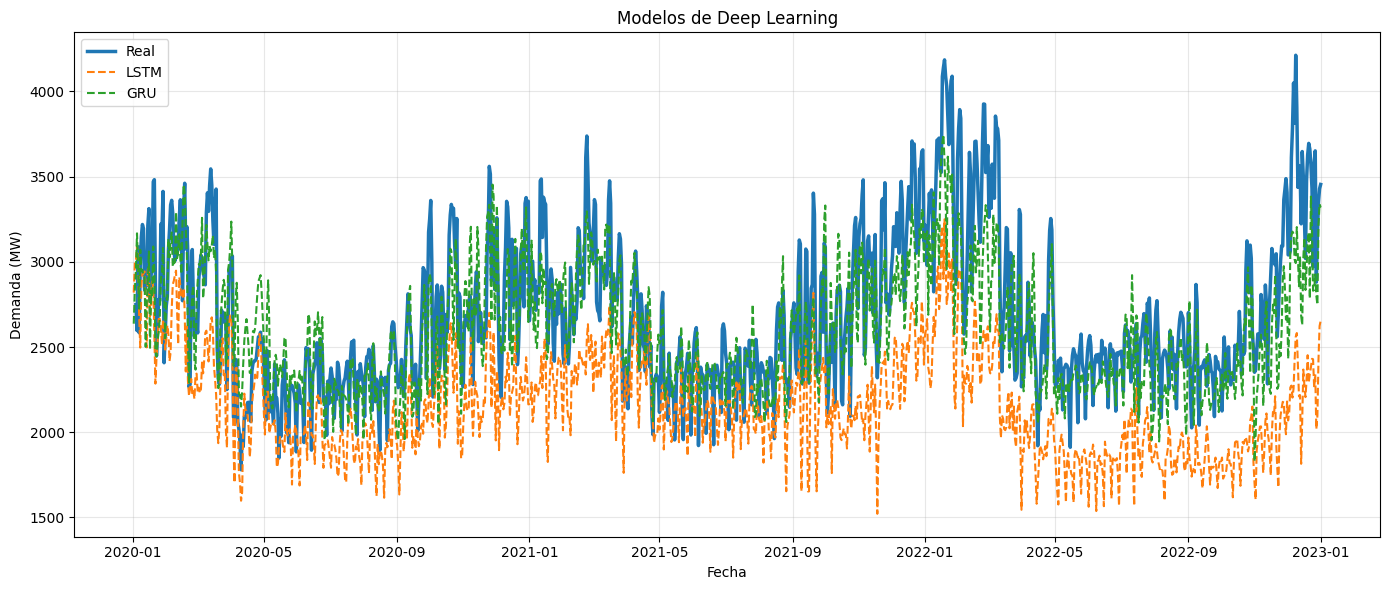

In [51]:
plt.figure(figsize=(14, 6))
plt.plot(y_test.index, y_test, label='Real', linewidth=2.5)

for nombre, pred in {
    'LSTM': pred_lstm,
    'GRU': pred_gru
}.items():
    plt.plot(pred.time_index, pred.values().flatten(), '--', label=nombre)

plt.title('Modelos de Deep Learning')
plt.xlabel('Fecha'); plt.ylabel('Demanda (MW)')
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

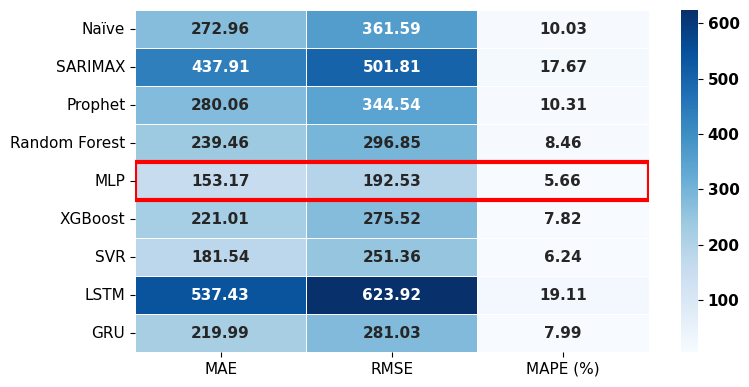

In [92]:
plt.rcParams['font.family']='sans-serif'; plt.rcParams['font.size']=11
metricas = pd.DataFrame({
    'MAE':[mae_naive,mae_sarimax,mae_prophet,mae_rf,mae_mlp,mae_xgb,mae_svr,mae_lstm,mae_gru],
    'RMSE':[rmse_naive,rmse_sarimax,rmse_prophet,rmse_rf,rmse_mlp,rmse_xgb,rmse_svr,rmse_lstm,rmse_gru],
    'MAPE (%)':[mape_naive,mape_sarimax,mape_prophet,mape_rf,mape_mlp,mape_xgb,mape_svr,mape_lstm,mape_gru]
}, index=['Naïve','SARIMAX','Prophet','Random Forest','MLP','XGBoost','SVR','LSTM','GRU'])
fig,ax=plt.subplots(figsize=(8,4))
sns.heatmap(metricas,annot=True,fmt='.2f',cmap='Blues',linewidths=.5,ax=ax)
ax.set_xticklabels(ax.get_xticklabels(),fontweight='normal'); ax.set_yticklabels(ax.get_yticklabels(),fontweight='normal')
i=metricas.index.get_loc('MLP'); ax.add_patch(plt.Rectangle((0,i),3,1,fill=False,edgecolor='red',linewidth=3))
plt.tight_layout(); plt.show()

# **IMPLEMENTACIÓN de una APP**

In [260]:
# @title Guardar
import joblib

# ============================================================
# GUARDAR MODELOS PARA LA APP
# ============================================================

joblib.dump(
    modelo_mlp,
    "modelo_mlp.pkl"
)

joblib.dump(
    modelo_svr,
    "modelo_svr.pkl"
)

joblib.dump(
    modelo_xgb,
    "modelo_xgb.pkl"
)

# Guardamos el scaler utilizado específicamente por MLP
joblib.dump(
    scaler_mlp,
    "scaler_mlp.pkl"
)

print("✅ Modelos guardados correctamente:")
print("   - modelo_mlp.pkl")
print("   - modelo_svr.pkl")
print("   - modelo_xgb.pkl")
print("   - scaler_mlp.pkl")

✅ Modelos guardados correctamente:
   - modelo_mlp.pkl
   - modelo_svr.pkl
   - modelo_xgb.pkl
   - scaler_mlp.pkl


In [261]:
modelo_lstm

RNNModel(model=LSTM, hidden_dim=64, n_rnn_layers=2, dropout=0.2, training_length=37, input_chunk_length=30, output_chunk_length=7, batch_size=16, n_epochs=50, optimizer_kwargs={'lr': 0.001}, random_state=42)

In [262]:
import os
print("PT:", os.path.exists("modelo_lstm.pt"))
print("CKPT:", os.path.exists("modelo_lstm.pt.ckpt"))

PT: True
CKPT: True


In [264]:
from darts.models import RNNModel

modelo_prueba = RNNModel.load("modelo_lstm.pt")

print(type(modelo_prueba))
print("Modelo cargado:", modelo_prueba._fit_called)

<class 'darts.models.forecasting.rnn_model.RNNModel'>
Modelo cargado: True


In [265]:
pred_prueba = modelo_prueba.predict(
    n=7,
    series=serie_train_s,
    future_covariates=cov_full_s
)

print("OK: el modelo guardado también predice")

INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs


Predicting: |          | 0/? [00:00<?, ?it/s]

OK: el modelo guardado también predice


In [266]:
print(type(modelo_lstm))
print("Modelo entrenado:", modelo_lstm._fit_called)

<class 'darts.models.forecasting.rnn_model.RNNModel'>
Modelo entrenado: True


In [267]:
pred_lstm_s = modelo_lstm.predict(
    n=7,
    series=serie_train_s,
    future_covariates=cov_full_s
)
print("Predicción realizada correctamente")
print(pred_lstm_s)

INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs


Predicting: |          | 0/? [00:00<?, ?it/s]

Predicción realizada correctamente
             SIN_max
DATETIME            
2020-01-02  0.712881
2020-01-03  0.783782
2020-01-04  0.789364
2020-01-05  0.826602
2020-01-06  0.800560
2020-01-07  0.654154
2020-01-08  0.580409

shape: (7, 1, 1), freq: D, size: 56.00 B


In [221]:
modelo_lstm.save("modelo_lstm.pt")

1. CREAR app.py

In [268]:
%%writefile app.py
# @title APP TOP 3 MODELOS
# ============================================================
# APP STREAMLIT - TOP 3 + LSTM
# Mantiene el diseño original de la aplicación
# ============================================================

import streamlit as st
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import joblib

from sklearn.metrics import mean_absolute_error, mean_squared_error

from darts import TimeSeries
from darts.models import RNNModel
from darts.dataprocessing.transformers import Scaler


# ============================================================
# CONFIGURACIÓN
# ============================================================

st.set_page_config(
    page_title="Predicción de la Demanda de Electricidad",
    page_icon="⚡",
    layout="wide"
)


# ============================================================
# DISEÑO ORIGINAL
# ============================================================

st.markdown("""
<style>

@import url('https://fonts.googleapis.com/css2?family=Inter:wght@400;500;600;700;800&display=swap');

html,body,[class*="css"]{
    font-family:'Inter',sans-serif
}

.stApp{
    background:#F5F8FC
}

.block-container{
    max-width:1450px;
    padding:35px 55px 50px
}

#MainMenu,header,footer{
    visibility:hidden
}

h1{
    color:#102A56!important;
    font-size:42px!important;
    font-weight:800!important
}

h2{
    color:#102A56!important;
    font-size:26px!important;
    font-weight:800!important
}

p,label{
    color:#000000!important;
    font-size:15px!important
}

[data-testid="stMetric"]{
    background:white;
    border:1px solid #DDE6F2;
    border-radius:18px;
    padding:24px 26px;
    min-height:135px;
    box-shadow:0 6px 18px rgba(25,55,95,.07)
}

[data-testid="stMetricLabel"]{
    color:#000000!important;
    font-size:14px!important;
    font-weight:600!important
}

[data-testid="stMetricValue"]{
    color:#102A56!important;
    font-size:30px!important;
    font-weight:800!important
}

div[data-baseweb="input"]{
    background:white;
    border-radius:12px;
    min-height:52px
}

div[data-baseweb="input"] input{
    font-size:17px!important;
    font-weight:600!important
}

.stButton>button{
    width:100%;
    min-height:54px;
    border:none;
    border-radius:13px;
    background:linear-gradient(135deg,#1264F4,#1749D2);
    color:white;
    font-size:16px;
    font-weight:800;
    box-shadow:0 8px 20px rgba(18,100,244,.25);
    transition:all .2s ease
}

.stButton>button:hover{
    transform:translateY(-2px);
    box-shadow:0 12px 25px rgba(18,100,244,.32)
}

[data-testid="stDataFrame"]{
    border-radius:14px;
    overflow:hidden;
    border:1px solid #DDE6F2
}

hr{
    border:none;
    border-top:1px solid #DCE5F0;
    margin:28px 0
}

</style>
""", unsafe_allow_html=True)


# ============================================================
# CARGAR DATOS Y MODELOS
# ============================================================

@st.cache_resource
def cargar_modelos():

    # --------------------------------------------------------
    # LSTM
    # --------------------------------------------------------

    modelo_lstm = RNNModel.load("modelo_lstm.pt")


    # --------------------------------------------------------
    # TOP 3
    # --------------------------------------------------------

    modelo_mlp = joblib.load("modelo_mlp.pkl")
    modelo_svr = joblib.load("modelo_svr.pkl")
    modelo_xgb = joblib.load("modelo_xgb.pkl")

    scaler_mlp = joblib.load("scaler_mlp.pkl")


    # --------------------------------------------------------
    # DATOS
    # --------------------------------------------------------

    df = pd.read_csv("complete-dataset.csv")

    df["DATETIME"] = pd.to_datetime(
        df["DATETIME"],
        utc=True
    )

    df = (
        df
        .sort_values("DATETIME")
        .set_index("DATETIME")
    )


    # --------------------------------------------------------
    # AGREGACIÓN DIARIA
    # --------------------------------------------------------

    diario = (
        df.resample("D")
        .agg({
            "SIN": "max",
            "T02M": "mean",
            "ISHOLIDAY": "max"
        })
        .dropna()
        .rename(columns={
            "SIN": "SIN_max"
        })
    )


    # --------------------------------------------------------
    # TRAIN / TEST PARA LSTM
    # --------------------------------------------------------

    n = int(len(diario) * 0.80)

    train = diario.iloc[:n]
    test = diario.iloc[n:]


    # --------------------------------------------------------
    # SERIES DARTS
    # --------------------------------------------------------

    serie = TimeSeries.from_dataframe(
        diario,
        value_cols="SIN_max"
    )

    cov = TimeSeries.from_dataframe(
        diario,
        value_cols=[
            "T02M",
            "ISHOLIDAY"
        ]
    )

    serie_train = TimeSeries.from_dataframe(
        train,
        value_cols="SIN_max"
    )

    cov_train = TimeSeries.from_dataframe(
        train,
        value_cols=[
            "T02M",
            "ISHOLIDAY"
        ]
    )


    # --------------------------------------------------------
    # ESCALADO LSTM
    # --------------------------------------------------------

    scaler_y = Scaler()
    scaler_x = Scaler()

    scaler_y.fit(serie_train)
    scaler_x.fit(cov_train)

    serie_s = scaler_y.transform(serie)
    cov_s = scaler_x.transform(cov)


    # --------------------------------------------------------
    # MÉTRICAS LSTM
    # --------------------------------------------------------

    pred_test_s = modelo_lstm.predict(
        n=len(test),
        series=serie_train,
        future_covariates=cov_s
    )

    pred_test = (
        scaler_y
        .inverse_transform(pred_test_s)
        .values()
        .flatten()
    )

    real_test = test["SIN_max"].values


    mae_lstm = mean_absolute_error(
        real_test,
        pred_test
    )

    rmse_lstm = np.sqrt(
        mean_squared_error(
            real_test,
            pred_test
        )
    )

    mape_lstm = np.mean(
        np.abs(
            (real_test - pred_test)
            / real_test
        )
    ) * 100


    return (
        modelo_lstm,
        modelo_mlp,
        modelo_svr,
        modelo_xgb,
        scaler_mlp,
        diario,
        serie_s,
        cov_s,
        scaler_y,
        (
            mae_lstm,
            rmse_lstm,
            mape_lstm
        )
    )


# ============================================================
# CARGAR MODELOS
# ============================================================

(
    modelo_lstm,
    modelo_mlp,
    modelo_svr,
    modelo_xgb,
    scaler_mlp,
    df_diario,
    serie_s,
    cov_s,
    scaler_y,
    metricas_lstm
) = cargar_modelos()


mae_lstm, rmse_lstm, mape_lstm = metricas_lstm


# ============================================================
# ENCABEZADO
# ============================================================

st.title(
    "⚡ Predicción de la Demanda de Electricidad (MW)"
)

st.caption(
    "Pronóstico de la demanda máxima diaria mediante modelos ML & DL."
)

st.divider()


# ============================================================
# MODELO DE PREDICCIÓN
# ============================================================

st.subheader("Modelo de predicción")

c1, c2, c3, c4 = st.columns(4)

c1.metric(
    "Modelos",
    "TOP 3 + LSTM",
    "Machine Learning & Deep Learning"
)

c2.metric(
    "Historial",
    "30 días",
    "Ventana de entrada"
)

c3.metric(
    "Horizonte",
    "7 días",
    "Pronóstico futuro"
)

c4.metric(
    "Variables",
    "9",
    "Features predictoras"
)


# ============================================================
# COMPARACIÓN DE MÉTRICAS
# ============================================================

st.subheader("Comparación de modelos")

col1, col2, col3, col4 = st.columns(4)

col1.metric(
    "MLP",
    "5.43 %",
    "MAPE"
)

col2.metric(
    "SVR",
    "6.24 %",
    "MAPE"
)

col3.metric(
    "XGBoost",
    "7.82 %",
    "MAPE"
)

col4.metric(
    "LSTM",
    f"{mape_lstm:.2f} %",
    "MAPE"
)

st.caption(
    "MLP, SVR y XGBoost corresponden a las métricas obtenidas "
    "en el notebook de evaluación."
)


# ============================================================
# SELECCIÓN DEL MODELO
# ============================================================

st.subheader("Seleccionar modelo")

modelo_seleccionado = st.selectbox(
    "Modelo para realizar el pronóstico",
    [
        "MLP",
        "SVR",
        "XGBoost",
        "LSTM"
    ]
)


# # ============================================================
# # MÉTRICAS DE LOS MODELOS
# # ============================================================

# metricas_modelos = {

#     "MLP": {
#         "MAE": 146.13,
#         "RMSE": 187.30,
#         "MAPE": 5.43
#     },

#     "SVR": {
#         "MAE": 181.54,
#         "RMSE": 251.36,
#         "MAPE": 6.24
#     },

#     "XGBoost": {
#         "MAE": 221.01,
#         "RMSE": 275.52,
#         "MAPE": 7.82
#     },

#     "LSTM": {
#         "MAE": mae_lstm,
#         "RMSE": rmse_lstm,
#         "MAPE": mape_lstm
#     }
# }


# metricas = metricas_modelos[
#     modelo_seleccionado
# ]


# st.subheader(
#     f"Métricas del modelo {modelo_seleccionado}"
# )

# m1, m2, m3 = st.columns(3)

# m1.metric(
#     "MAE",
#     f"{metricas['MAE']:,.2f} MW"
# )

# m2.metric(
#     "RMSE",
#     f"{metricas['RMSE']:,.2f} MW"
# )

# m3.metric(
#     "MAPE",
#     f"{metricas['MAPE']:.2f} %"
# )


# ============================================================
# FECHA
# ============================================================

st.subheader("Generar pronóstico")

st.write(
    "Seleccione una fecha de referencia para estimar "
    "la demanda máxima de los siguientes 7 días."
)

col_fecha, col_boton = st.columns([2.8, 1])

with col_fecha:

    fecha = st.date_input(
        "Fecha de referencia",
        value=df_diario.index[-8].date()
    )

with col_boton:

    st.write("")
    st.write("")

    ejecutar = st.button(
        "⚡ GENERAR PREDICCIÓN"
    )


# ============================================================
# FEATURES TOP 3
# ============================================================

FEATURES = [
    "lag_1",
    "lag_2",
    "lag_3",
    "lag_7",
    "lag_14",
    "T02M",
    "ISHOLIDAY",
    "dayofweek",
    "month"
]


def crear_features(
    df,
    fecha,
    historial
):

    fila = {}

    fila["lag_1"] = historial.iloc[-1]

    fila["lag_2"] = historial.iloc[-2]

    fila["lag_3"] = historial.iloc[-3]

    fila["lag_7"] = historial.iloc[-7]

    fila["lag_14"] = historial.iloc[-14]

    fila["T02M"] = df.loc[
        fecha,
        "T02M"
    ]

    fila["ISHOLIDAY"] = df.loc[
        fecha,
        "ISHOLIDAY"
    ]

    fila["dayofweek"] = fecha.dayofweek

    fila["month"] = fecha.month

    return pd.DataFrame(
        [fila],
        columns=FEATURES
    )


# ============================================================
# PREDICCIÓN TOP 3
# ============================================================

def predecir_ml(
    nombre_modelo,
    fecha_inicio,
    df
):

    historial = df.loc[
        :fecha_inicio,
        "SIN_max"
    ].copy()

    resultados = []
    fechas = []


    for i in range(1, 8):

        fecha_futura = (
            fecha_inicio
            + pd.Timedelta(days=i)
        )


        X = crear_features(
            df,
            fecha_futura,
            historial
        )


        # ----------------------------------------------------
        # MLP
        # ----------------------------------------------------

        if nombre_modelo == "MLP":

            X_scaled = scaler_mlp.transform(X)

            pred = modelo_mlp.predict(
                X_scaled
            )[0]


        # ----------------------------------------------------
        # SVR
        # ----------------------------------------------------

        elif nombre_modelo == "SVR":

            pred = modelo_svr.predict(
                X
            )[0]


        # ----------------------------------------------------
        # XGBoost
        # ----------------------------------------------------

        elif nombre_modelo == "XGBoost":

            pred = modelo_xgb.predict(
                X
            )[0]


        resultados.append(
            float(pred)
        )

        fechas.append(
            fecha_futura
        )


        # ----------------------------------------------------
        # PREDICCIÓN RECURSIVA
        # ----------------------------------------------------

        historial.loc[
            fecha_futura
        ] = pred


    return (
        pd.DatetimeIndex(fechas),
        np.array(resultados)
    )


# ============================================================
# PREDICCIÓN
# ============================================================

if ejecutar:

    fecha = pd.Timestamp(
        fecha,
        tz="UTC"
    )


    # --------------------------------------------------------
    # VALIDACIÓN DE FECHA
    # --------------------------------------------------------

    if fecha not in df_diario.index:

        st.error(
            "La fecha seleccionada no existe."
        )

    else:

        pos = df_diario.index.get_loc(
            fecha
        )


        # ----------------------------------------------------
        # VALIDACIÓN HISTORIAL
        # ----------------------------------------------------

        if pos < 29:

            st.error(
                "Se necesitan al menos 30 días anteriores."
            )


        # ----------------------------------------------------
        # VALIDACIÓN HORIZONTE
        # ----------------------------------------------------

        elif pos + 7 >= len(df_diario):

            st.error(
                "No existen 7 días posteriores disponibles."
            )


        else:

            # =================================================
            # PREDICCIÓN
            # =================================================

            with st.spinner(
                f"Generando predicción con "
                f"{modelo_seleccionado}..."
            ):

                # ---------------------------------------------
                # LSTM
                # ---------------------------------------------

                if modelo_seleccionado == "LSTM":

                    pred_s = modelo_lstm.predict(
                        n=7,
                        series=serie_s[:pos + 1],
                        future_covariates=cov_s
                    )

                    pred = scaler_y.inverse_transform(
                        pred_s
                    )

                    fechas_pred = (
                        df_diario
                        .index[pos + 1:pos + 8]
                    )

                    valores_pred = (
                        pred
                        .values()
                        .flatten()
                    )


                # ---------------------------------------------
                # TOP 3
                # ---------------------------------------------

                else:

                    fechas_pred, valores_pred = predecir_ml(
                        modelo_seleccionado,
                        fecha,
                        df_diario
                    )


            # =================================================
            # RESUMEN
            # =================================================

            st.subheader(
                f"Resumen del pronóstico · "
                f"{modelo_seleccionado}"
            )

            r1, r2, r3, r4 = st.columns(4)

            r1.metric(
                "Promedio",
                f"{valores_pred.mean():,.0f} MW"
            )

            r2.metric(
                "Máximo previsto",
                f"{valores_pred.max():,.0f} MW"
            )

            r3.metric(
                "Mínimo previsto",
                f"{valores_pred.min():,.0f} MW"
            )

            r4.metric(
                "Pico esperado",
                fechas_pred[
                    valores_pred.argmax()
                ].strftime("%d/%m/%Y")
            )


            # =================================================
            # GRÁFICO
            # =================================================

            st.subheader(
                f"Demanda real vs. predicción "
                f"{modelo_seleccionado}"
            )

            st.caption(
                "Comportamiento observado y pronóstico "
                "de los siguientes 7 días."
            )


            fechas_hist = (
                df_diario
                .index[pos - 29:pos + 1]
            )

            valores_real = (
                df_diario
                .loc[
                    fechas_hist,
                    "SIN_max"
                ]
                .values
            )


            fig, ax = plt.subplots(
                figsize=(15, 6.5),
                dpi=140
            )

            fig.patch.set_facecolor(
                "#FFFFFF"
            )

            ax.set_facecolor(
                "#FFFFFF"
            )


            # -------------------------------------------------
            # REAL
            # -------------------------------------------------

            ax.plot(
                fechas_hist,
                valores_real,
                color="#1677FF",
                linewidth=3,
                marker="o",
                markersize=5,
                markerfacecolor="#1677FF",
                markeredgecolor="white",
                markeredgewidth=1.2,
                label="Real",
                zorder=3
            )

            ax.fill_between(
                fechas_hist,
                valores_real,
                alpha=.08,
                color="#1677FF",
                zorder=1
            )


            # -------------------------------------------------
            # PREDICCIÓN
            # -------------------------------------------------

            ax.plot(
                fechas_pred,
                valores_pred,
                color="#FF8500",
                linewidth=3,
                linestyle="--",
                marker="o",
                markersize=6,
                markerfacecolor="#FF8500",
                markeredgecolor="white",
                markeredgewidth=1.2,
                label=modelo_seleccionado,
                zorder=4
            )

            ax.fill_between(
                fechas_pred,
                valores_pred,
                alpha=.10,
                color="#FF8500",
                zorder=1
            )


            ax.xaxis.set_major_locator(
                mdates.DayLocator(interval=4)
            )

            ax.xaxis.set_major_formatter(
                mdates.DateFormatter("%Y-%m-%d")
            )

            plt.setp(
                ax.get_xticklabels(),
                rotation=0,
                ha="center"
            )


            ax.set_ylabel(
                "MW",
                fontsize=16,
                fontweight="700"
            )

            ax.set_xlabel(
                "Fecha",
                fontsize=15,
                fontweight="600"
            )


            ax.tick_params(
                axis="both",
                labelsize=11,
                colors="#334155"
            )


            ax.grid(
                True,
                axis="both",
                color="#CBD5E1",
                alpha=.35
            )


            ax.spines["top"].set_visible(
                False
            )

            ax.spines["right"].set_visible(
                False
            )

            ax.spines["left"].set_color(
                "#64748B"
            )

            ax.spines["bottom"].set_color(
                "#64748B"
            )


            legend = ax.legend(
                loc="upper left",
                fontsize=13,
                frameon=True,
                fancybox=True,
                framealpha=.95
            )

            legend.get_frame().set_edgecolor(
                "#E2E8F0"
            )


            ax.margins(
                x=.02,
                y=.10
            )


            fig.tight_layout(
                pad=1.5
            )


            st.pyplot(
                fig,
                use_container_width=True
            )

            plt.close(fig)


            # =================================================
            # TABLA DEL MODELO SELECCIONADO
            # =================================================

            st.subheader(
                "Pronóstico de los próximos 7 días"
            )


            resultado = pd.DataFrame({

                "Fecha":
                    fechas_pred.strftime(
                        "%d/%m/%Y"
                    ),

                "Demanda máxima (MW)":
                    [
                        f"{x:,.0f}"
                        for x in valores_pred
                    ]
            })


            st.dataframe(
                resultado,
                use_container_width=True,
                hide_index=True
            )


            # =================================================
            # COMPARACIÓN DE TODOS LOS MODELOS
            # =================================================

            st.divider()

            st.subheader(
                "Comparación de predicciones · "
                "Todos los modelos"
            )

            st.caption(
                "Comparación de la demanda prevista para "
                "los mismos 7 días mediante MLP, SVR, "
                "XGBoost y LSTM."
            )


            # =================================================
            # GENERAR PREDICCIONES DE LOS 4 MODELOS
            # =================================================

            with st.spinner(
                "Calculando comparación de todos los modelos..."
            ):

                # ------------------------------------------------
                # TOP 3
                # ------------------------------------------------

                fechas_comparacion, pred_mlp = predecir_ml(
                    "MLP",
                    fecha,
                    df_diario
                )

                _, pred_svr = predecir_ml(
                    "SVR",
                    fecha,
                    df_diario
                )

                _, pred_xgb = predecir_ml(
                    "XGBoost",
                    fecha,
                    df_diario
                )


                # ------------------------------------------------
                # LSTM
                # ------------------------------------------------

                pred_lstm_s = modelo_lstm.predict(
                    n=7,
                    series=serie_s[:pos + 1],
                    future_covariates=cov_s
                )

                pred_lstm = (
                    scaler_y
                    .inverse_transform(
                        pred_lstm_s
                    )
                    .values()
                    .flatten()
                )


            # =================================================
            # DATAFRAME COMPARATIVO
            # =================================================

            comparacion = pd.DataFrame({

                "Fecha":
                    fechas_comparacion,

                "MLP":
                    pred_mlp,

                "SVR":
                    pred_svr,

                "XGBoost":
                    pred_xgb,

                "LSTM":
                    pred_lstm

            })


            # =================================================
            # GRÁFICA COMPARATIVA
            # =================================================

            st.subheader(
                "Comparación visual de predicciones"
            )

            fig_comp, ax_comp = plt.subplots(
                figsize=(15, 7),
                dpi=140
            )

            fig_comp.patch.set_facecolor(
                "#FFFFFF"
            )

            ax_comp.set_facecolor(
                "#FFFFFF"
            )


            # ------------------------------------------------
            # MLP
            # ------------------------------------------------

            ax_comp.plot(
                fechas_comparacion,
                pred_mlp,
                linewidth=3,
                marker="o",
                markersize=6,
                label="MLP"
            )


            # ------------------------------------------------
            # SVR
            # ------------------------------------------------

            ax_comp.plot(
                fechas_comparacion,
                pred_svr,
                linewidth=3,
                marker="o",
                markersize=6,
                label="SVR"
            )


            # ------------------------------------------------
            # XGBoost
            # ------------------------------------------------

            ax_comp.plot(
                fechas_comparacion,
                pred_xgb,
                linewidth=3,
                marker="o",
                markersize=6,
                label="XGBoost"
            )


            # ------------------------------------------------
            # LSTM
            # ------------------------------------------------

            ax_comp.plot(
                fechas_comparacion,
                pred_lstm,
                linewidth=3,
                marker="o",
                markersize=6,
                label="LSTM"
            )


            # ------------------------------------------------
            # FORMATO
            # ------------------------------------------------

            ax_comp.xaxis.set_major_locator(
                mdates.DayLocator()
            )

            ax_comp.xaxis.set_major_formatter(
                mdates.DateFormatter("%d/%m")
            )

            plt.setp(
                ax_comp.get_xticklabels(),
                rotation=0,
                ha="center"
            )


            ax_comp.set_xlabel(
                "Fecha",
                fontsize=15,
                fontweight="600"
            )

            ax_comp.set_ylabel(
                "Demanda máxima (MW)",
                fontsize=15,
                fontweight="700"
            )


            ax_comp.tick_params(
                axis="both",
                labelsize=11,
                colors="#334155"
            )


            ax_comp.grid(
                True,
                axis="both",
                color="#CBD5E1",
                alpha=.35
            )


            ax_comp.spines[
                "top"
            ].set_visible(False)

            ax_comp.spines[
                "right"
            ].set_visible(False)

            ax_comp.spines[
                "left"
            ].set_color("#64748B")

            ax_comp.spines[
                "bottom"
            ].set_color("#64748B")


            ax_comp.legend(
                loc="upper left",
                fontsize=12,
                frameon=True,
                fancybox=True
            )


            ax_comp.margins(
                x=.02,
                y=.10
            )


            fig_comp.tight_layout(
                pad=1.5
            )


            st.pyplot(
                fig_comp,
                use_container_width=True
            )

            plt.close(fig_comp)


            # =================================================
            # TABLA RESUMEN DE PICOS
            # =================================================

            st.subheader(
                "Resumen de picos pronosticados"
            )


            def obtener_pico(
                nombre,
                fechas,
                valores
            ):

                indice = np.argmax(
                    valores
                )

                return {
                    "Modelo":
                        nombre,

                    "Pico previsto (MW)":
                        round(
                            float(
                                valores[indice]
                            ),
                            0
                        ),

                    "Fecha del pico":
                        fechas[indice].strftime(
                            "%d/%m/%Y"
                        )
                }


            tabla_picos = pd.DataFrame([

                obtener_pico(
                    "MLP",
                    fechas_comparacion,
                    pred_mlp
                ),

                obtener_pico(
                    "SVR",
                    fechas_comparacion,
                    pred_svr
                ),

                obtener_pico(
                    "XGBoost",
                    fechas_comparacion,
                    pred_xgb
                ),

                obtener_pico(
                    "LSTM",
                    fechas_comparacion,
                    pred_lstm
                )

            ])


            st.dataframe(
                tabla_picos,
                use_container_width=True,
                hide_index=True
            )


# ============================================================
# PIE
# ============================================================

st.divider()

st.caption(
    "Proyecto de Forecasting Energético · "
    "TOP 3 ML + LSTM · 2026"
)

Overwriting app.py


2. Verificar archivos

In [276]:
import os

print("app.py:", os.path.exists("app.py"))
print("modelo_lstm.pt:", os.path.exists("modelo_lstm.pt"))
print("modelo_lstm.pt.ckpt:", os.path.exists("modelo_lstm.pt.ckpt"))
print("complete-dataset.csv:", os.path.exists("complete-dataset.csv"))

app.py: True
modelo_lstm.pt: True
modelo_lstm.pt.ckpt: True
complete-dataset.csv: True


3. Instalar Streamlit y pyngrok

In [277]:
!pip install -q streamlit pyngrok

4. Detener Streamlit anterior

In [278]:
!pkill -f streamlit

5. Ejecutar Streamlit

In [279]:
!streamlit run app.py &>/content/log.txt &

6. Revisar que Streamlit arrancó correctamente

In [280]:
!cat /content/log.txt

In [281]:
!pip install pyngrok
from pyngrok import ngrok
ngrok.set_auth_token("3Jn89jwh24GEs6s7POaKwgAX8Lu_5G8pJe5g3wi8BbH4YMpwn")

7. Configurar ngrok

In [282]:
from pyngrok import ngrok

ngrok.kill()
!pkill -f ngrok
public_url = ngrok.connect(8501)
print(public_url)

NgrokTunnel: "https://customer-janitor-bovine.ngrok-free.dev" -> "http://localhost:8501"
